In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

DISTANCE_MIN, DISTANCE_MAX = 10, 500
POWER_MIN, POWER_MAX = 10, 30
BANDWIDTH_MIN, BANDWIDTH_MAX = 1, 20
INTERFERENCE_MIN, INTERFERENCE_MAX = 0.1, 2.0
NOISE_POWER = 1e-9
NUM_SIMULATIONS = 1000

In [2]:
data = []

for _ in range(NUM_SIMULATIONS):

    distance = np.random.uniform(DISTANCE_MIN, DISTANCE_MAX)
    power = np.random.uniform(POWER_MIN, POWER_MAX)
    bandwidth = np.random.uniform(BANDWIDTH_MIN, BANDWIDTH_MAX)
    interference = np.random.uniform(INTERFERENCE_MIN, INTERFERENCE_MAX)

    path_loss = 20 * np.log10(distance)

    received_power = power - path_loss

    snr = (10**(received_power/10)) / (NOISE_POWER * interference)

    shannon_capacity = bandwidth * np.log2(1 + snr)

    data.append([distance, power, bandwidth, interference, shannon_capacity])

df = pd.DataFrame(data, columns=[
    "Distance",
    "Transmission_Power",
    "Bandwidth",
    "Interference",
    "Throughput"
])

df.head()

,Distance,Transmission_Power,Bandwidth,Interference,Throughput
0,446.485013,23.863291,1.118396,0.697696,23.194372
1,124.260518,27.751995,2.439447,1.464609,60.135784
2,275.304445,29.015914,5.820281,1.561378,132.025175
3,311.700120,19.562035,3.085291,0.831795,61.993969
4,157.473894,11.262799,12.343901,0.520539,246.665211


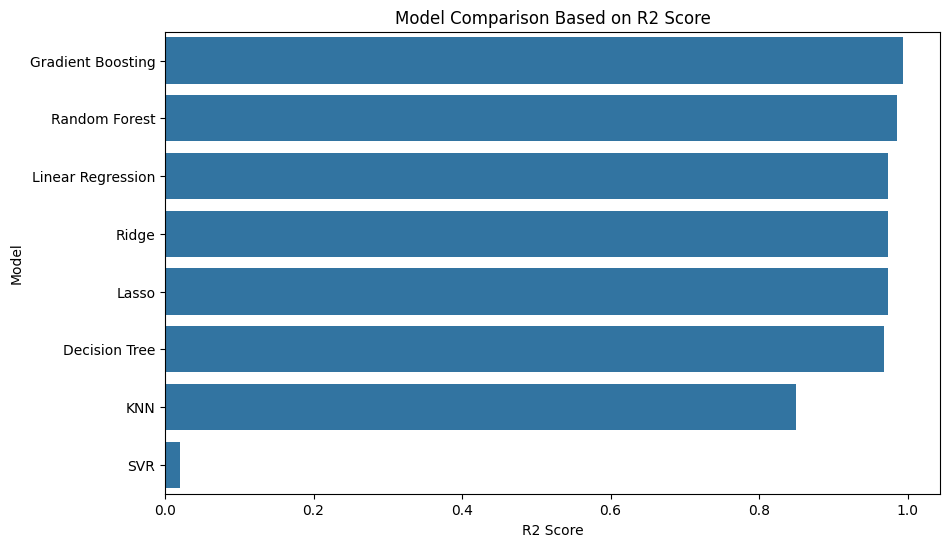

In [5]:
X = df.drop("Throughput", axis=1)
y = df["Throughput"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append([name, mse, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2 Score"])
results_df.sort_values(by="R2 Score", ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x="R2 Score", y="Model", data=results_df.sort_values("R2 Score", ascending=False))
plt.title("Model Comparison Based on R2 Score")
plt.show()